In [22]:
from langgraph.graph import StateGraph,END
from typing import TypedDict,List
import random

In [23]:
class LoopState(TypedDict):
    player_name: str
    guesses: List[int]
    target_num: int
    attempts: int
    lower_bound: int
    upper_bound: int
    hint: str

In [24]:
def setup(state: LoopState) -> LoopState:
    state["attempts"] = 0
    state["lower_bound"] = 1
    state["upper_bound"] = 20
    state["target_num"] = random.randint(1, 20)
    state["hint"] = f'游戏开始，请{state["player_name"]}猜数'
    return state

In [70]:
# 如果猜对，不会进这个循环
def guess(state: LoopState) -> LoopState:
    if len(state["guesses"]) == 0:
        pass
    elif state["hint"] == "猜大了":
        state["upper_bound"] = state["guesses"][-1] - 1
    else:
        state["lower_bound"] = state["guesses"][-1] + 1
    guess = random.randint(state["lower_bound"],state["upper_bound"])
    state["guesses"].append(guess)
    state["attempts"] += 1
    return state

In [71]:
def hint(state: LoopState) -> LoopState:
    user_guess = state["guesses"][-1]
    if user_guess == state["target_num"]:
        state["hint"] = "猜对了"
    elif user_guess > state["target_num"]:
        state["hint"] = "猜大了"
    else:
        state["hint"] = "猜小了"
    return state

In [72]:
# 判断只在loop做，其他不要做判断
def loop(state: LoopState) -> str:
    if state["attempts"] >= 7 or state["hint"] == "猜对了":
        return "end"
    else:
        return "continue"

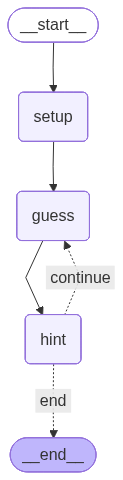

In [73]:
graph = StateGraph(LoopState)

# 说白了，第二个参数这个节点会怎么传state
graph.add_node("setup", setup)
graph.add_node("guess", guess)
graph.add_node("hint", hint)

# loop不是graph节点，所以不需要加入图；router是图节点，所以需要加入图
# graph.add_node("loop", lambda state: state)

graph.set_entry_point("setup")
graph.add_edge("setup", "guess")
graph.add_edge("guess", "hint")

graph.add_conditional_edges(
    # source node
    "hint",
    # action
    loop,
    {
        "end": END,
        "continue": "guess"
    }
)

graph.compile()

In [121]:
app = graph.compile()
app.invoke({"player_name":"祝坤鹏","guesses":[]})

{'player_name': '祝坤鹏',
 'guesses': [1, 16, 10, 3, 7, 6, 4],
 'target_num': 5,
 'attempts': 7,
 'lower_bound': 4,
 'upper_bound': 5,
 'hint': '猜小了'}